In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

df = pd.read_csv("retail_sales_dataset.csv")

Dataset Shape
(4310, 21)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   object 
 1   order_date             4280 non-null   object 
 2   customer_id            4280 non-null   object 
 3   customer_name          4280 non-null   object 
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   object 
 6   region                 4280 non-null   object 
 7   city                   4280 non-null   object 
 8   product_category       4280 non-null   object 
 9   product_name           4280 non-null   object 
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit    

/tmp/ipykernel_663/3194792145.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


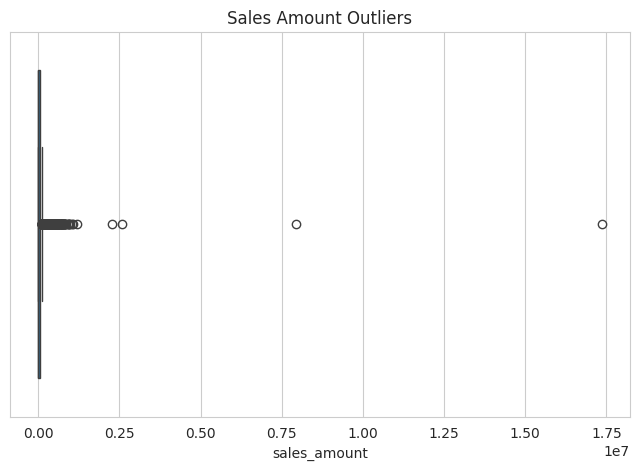

In [11]:


print("Dataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

# -----------------------------
# Fill Missing Values
# -----------------------------

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning")

print(df.isnull().sum())

# -----------------------------
# Duplicate Rows
# -----------------------------

print("\nDuplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates")

print(df.shape)

# -----------------------------
# Outlier Detection
# -----------------------------

Q1 = df["sales_amount"].quantile(0.25)

Q3 = df["sales_amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["sales_amount"] < lower) |
    (df["sales_amount"] > upper)
]

print("\nNumber of Outliers :", len(outliers))

print(outliers.head())

# -----------------------------
# Box Plot
# -----------------------------

plt.figure(figsize=(8,5))

sns.boxplot(x=df["sales_amount"])

plt.title("Sales Amount Outliers")

plt.show()

In [12]:
# =====================================================
# EXPERIMENT 3
# Part 2
# =====================================================

# -----------------------------
# Min-Max Normalization
# -----------------------------

scaler = MinMaxScaler()

df[["sales_amount"]] = scaler.fit_transform(
    df[["sales_amount"]]
)

print("Normalized Sales Amount")

print(df[["sales_amount"]].head())

# -----------------------------
# Label Encoding
# -----------------------------

encoder = LabelEncoder()

df["order_status"] = encoder.fit_transform(
    df["order_status"]
)

print("\nEncoded Order Status")

print(df[["order_status"]].head())

# -----------------------------
# One Hot Encoding
# -----------------------------

region_encoded = pd.get_dummies(
    df["region"],
    prefix="Region"
)

print("\nOne Hot Encoded Region")

print(region_encoded.head())

# -----------------------------
# Merge Encoded Columns
# -----------------------------

df = pd.concat(
    [df, region_encoded],
    axis=1
)

print("\nDataset After Encoding")

print(df.head())

# -----------------------------
# Save Cleaned Dataset
# -----------------------------

df.to_csv(
    "cleaned_retail_sales_dataset.csv",
    index=False
)

print("\nCleaned Dataset Saved Successfully!")

Normalized Sales Amount
   sales_amount
0      0.000231
1      0.000525
2      0.006343
3      0.015093
4      0.000016

Encoded Order Status
   order_status
0             3
1             1
2             1
3             1
4             2

One Hot Encoded Region
   Region_Central  Region_East  Region_North  Region_South  Region_West
0            True        False         False         False        False
1           False        False         False         False         True
2           False        False         False         False         True
3           False        False         False         False         True
4            True        False         False         False        False

Dataset After Encoding
    order_id  order_date customer_id customer_name   age gender   region  \
0  ORD-03903  2024-08-15   CUST32603   Aarav Mehta  39.0  Other  Central   
1  ORD-02198  2022-08-16   CUST07881  Sanjay Verma  28.0   Male     West   
2  ORD-01348  2021-08-29   CUST49296  Pooja Sharma  41